In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import gaussian_filter1d

In [54]:
sm=1

In [139]:
# Load the data
df = pd.read_csv(
    './H3K9me3/2024_fountain_1.mat.gz',
    compression='gzip', sep='\t', skiprows=[0], header=None
)
df = df.fillna(0.0)
df = df.drop([0, 1, 2, 3, 4, 5], axis=1)
ctcf_array = df.to_numpy()
df 

,6,7,8,9,10,11,12,13,14,15,...,136,137,138,139,140,141,142,143,144,145
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.056952,0.157409,0.061698,0.069608,0.161364,0.099666,0.061698,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.004746,0.090965,0.087801,0.211988,0.088592,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3756,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3757,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3758,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [123]:
# ========================
# USER / HARDCODED SETUP
# ========================
# Order here MUST match the column layout in ctcf_array along axis=1
var_names = [
    "WT_HU",
    "BRCA2_3HRS"
]

# Number of splits = number of names
n_splits = len(var_names)

# ========================
# SPLIT ONCE
# ========================
split_arrays = np.split(ctcf_array, n_splits, axis=1)

# Map each name -> its slice
arrays = {name: arr for name, arr in zip(var_names, split_arrays)}

# ========================
# STATS CONTAINERS
# ========================
means = {}
stds_early = {}
means_early = {}

# ========================
# LOOP OVER ALL NAMED SLICES
# ========================
for name in var_names:
    # skip x (coordinate axis)
    if name == "x":
        continue

    arr = arrays[name]              # shape (N, M)
    mask = arr != 0                 # ignore zeros
    count = np.sum(mask, axis=0)    # per-column nonzero counts

    mean = np.zeros(arr.shape[1], dtype=float)
    std = np.zeros(arr.shape[1], dtype=float)

    valid = count > 0               # avoid division by zero

    # mean over non-zero entries
    mean[valid] = (
        np.sum(arr[:, valid] * mask[:, valid], axis=0) / count[valid]
    )

    # std over non-zero entries
    std[valid] = np.sqrt(
        np.sum(
            mask[:, valid] * (arr[:, valid] - mean[valid]) ** 2,
            axis=0
        ) / count[valid]
    )

    means[name] = mean
    stds_early[name] = std
    means_early[name] = gaussian_filter1d(mean, sigma=sm)


# shift = np.min(means_early['G9ai']) - 0.01
# means_early['WT_HU'] = np.array(means_early['WT_HU']) - shift

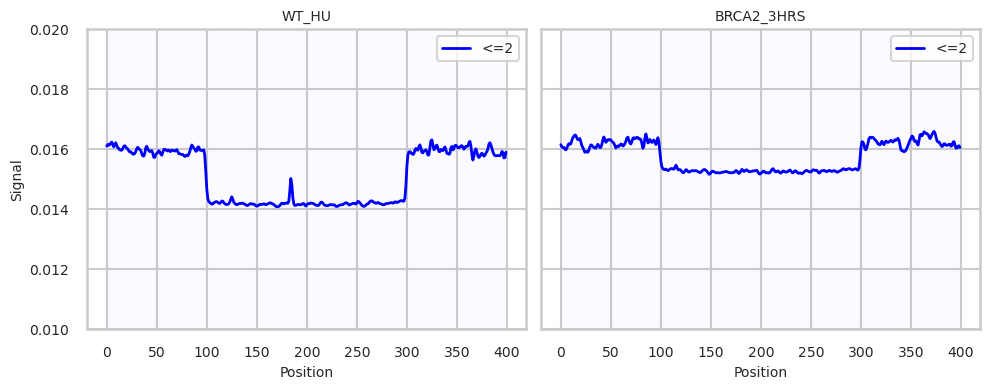

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# FONT CONFIG (user change here)
# ==========================
FONT_FAMILY = "DejaVu Sans"   # change to "Arial" on a machine that has it
FONT_SIZE   = 10             # global font size

plt.rcParams.update({
    "font.family":      FONT_FAMILY,
    "font.size":        FONT_SIZE,
    "axes.titlesize":   FONT_SIZE,
    "axes.labelsize":   FONT_SIZE,
    "xtick.labelsize":  FONT_SIZE,
    "ytick.labelsize":  FONT_SIZE,
    "legend.fontsize":  FONT_SIZE,
})

# --------------------------
# PLOTTING
# --------------------------
y_min, y_max = 0.01, 0.02

# x-axis = index from 0..L-1 (all conditions assumed same length)
L = len(next(iter(means_early.values())))
x_vals = np.arange(L)

fig, axes = plt.subplots(
    1,
    len(var_names),
    figsize=(5 * len(var_names), 4),
    sharey=True
)

# If only one condition, axes is a single Axes; normalize to list
if len(var_names) == 1:
    axes = [axes]

def plot_with_error(ax, name):
    # ----- dataset A: normal -----
    mean_a = means_early[name]
    std_a  = stds_early[name]
    yerr = 0.1

    sns.lineplot(
        x=x_vals,
        y=mean_a,
        ax=ax,
        marker='None',
        linestyle='-',
        color='blue',
        linewidth=2, 
        label='<=2'
    )

    ax.errorbar(
        x_vals,
        mean_a,
        yerr=0000.1,
        fmt='None',
        capsize=0.2,
        capthick=0.1,
        elinewidth=0.01,
        color='blue',
        alpha=1,
    )

    ax.set_title(name)
    ax.set_xlabel("Position")
    ax.invert_yaxis()
    ax.set_ylim(y_min, y_max)

for ax, name in zip(axes, var_names):
    plot_with_error(ax, name)

axes[0].set_ylabel("Signal")
# axes[0].legend(title="Dataset")  # A = normal, B = _b

plt.tight_layout()
# plt.savefig("ctcf_profiles_AB.svg", format="svg", dpi=1200)
plt.show()

/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_4620/1829317013.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


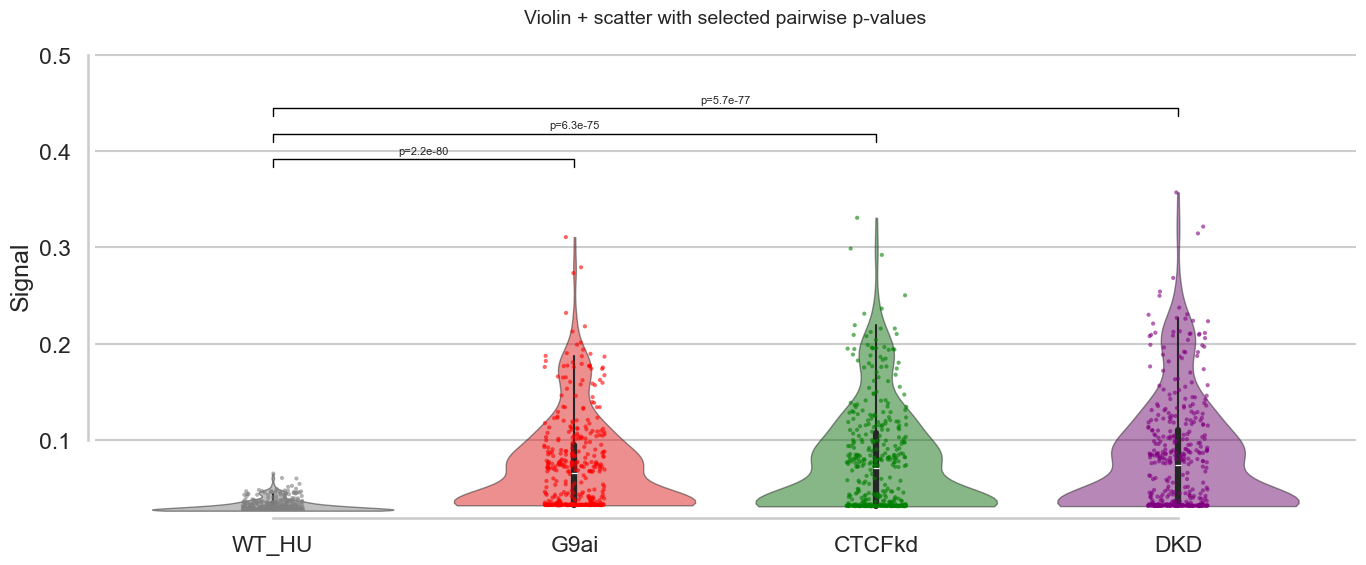

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
data = means_early

# WT baseline
WT_KEY = "WT_HU"

# ------------------------------------------------------------
# 2) Conditions to plot (UT and WT_BrdU_FT removed)
# ------------------------------------------------------------
order = [
    "WT_HU", 
    "G9ai", 
    "CTCFkd", 
    "DKD", 
]

# ------------------------------------------------------------
# 3) Tidy DataFrame
# ------------------------------------------------------------
rows = []
for cond in order:
    arr = data[cond]
    for v in arr:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 4) Palette: WT/G9ai/CTCFkd/DKD with lighter mirin shades
# ------------------------------------------------------------
cond_palette = {
    "WT_HU":      "grey",
    "G9ai":       "red",
    "CTCFkd":       "green",
    "DKD":       "purple"
}

# ------------------------------------------------------------
# 5) Violin + scatter
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=df,
    x="Condition", y="Value",
    order=order,
    palette=cond_palette,
    inner="box",
    cut=0,
    linewidth=1.0,
    ax=ax,
    alpha=0.5
)

sns.stripplot(
    data=df,
    x="Condition", y="Value",
    order=order,
    hue="Condition",
    hue_order=order,
    palette=cond_palette,
    dodge=False,
    size=3,
    alpha=0.6,
    legend=False,
    ax=ax
)

# ------------------------------------------------------------
# 6) Define specific comparison pairs
# ------------------------------------------------------------
pairs = []

# WT vs {G9ai, CTCFkd, DKD, WT_mirin}
pairs.extend([
    (WT_KEY, "G9ai"),
    (WT_KEY, "CTCFkd"),
    (WT_KEY, "DKD")
])

# WT_mirin vs {G9ai_mirin, CTCFkd_mirin, DKD_mirin}
# pairs.extend([
#     ("WT_mirin"),
#     ("WT_mirin", "CTCFkd_mirin"),
#     ("WT_mirin", "DKD_mirin"),
# ])

# IR vs {WT, WT_mirin}
# pairs.extend([
#     ("IR", WT_KEY),
#     ("IR", "WT_mirin"),
# ])

# ------------------------------------------------------------
# 7) Compute and plot p-values (Mann–Whitney U)
# ------------------------------------------------------------
y_min = df["Value"].min()
y_max = df["Value"].max()
step = (y_max - y_min) * 0.08   # vertical spacing between brackets
top = y_max

for i, (c1, c2) in enumerate(pairs):
    x1 = order.index(c1)
    x2 = order.index(c2)

    g1 = df.loc[df["Condition"] == c1, "Value"]
    g2 = df.loc[df["Condition"] == c2, "Value"]

    stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

    y = top + step * (i + 1)
    y_top = y + 0.3 * step
    y_text = y + 0.45 * step

    # bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.0,
        c="black"
    )

    # p-value text
    ax.text(
        (x1 + x2) / 2,
        y_text,
        f"p={pval:.1e}",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_ylim(y_min, top + step * (len(pairs) + 3))

# ------------------------------------------------------------
# 8) Cosmetics
# ------------------------------------------------------------
ax.set_title("Violin + scatter with selected pairwise p-values", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Signal")
plt.xticks(rotation=90)
sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.savefig("./fig_1/hct_3hrs_lessthan2_violin.svg", format="svg", dpi=1200)
plt.show()


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from itertools import combinations

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
# means_early must be a dict-like: key -> 1D array/list of values
data = means_early

# WT baseline key
WT_KEY = "WT_HU"

# conditions to use
order = [
    "WT_HU",
    "G9ai",
    "CTCFkd",
    "DKD",
]

# ------------------------------------------------------------
# 2) Tidy DataFrame with raw values
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 3) Palette
# ------------------------------------------------------------
cond_palette = {
    "WT_HU":  "grey",
    "G9ai":   "red",
    "CTCFkd": "green",
    "DKD":    "purple",
}

# ------------------------------------------------------------
# 4) Compute fold change vs WT_HU (per condition)
# ------------------------------------------------------------
wt_vals = np.asarray(data[WT_KEY], dtype=float)
wt_mean = wt_vals.mean()

plot_conds = order  # same as order, but kept explicit

fc_means = []
fc_sems  = []

for cond in plot_conds:
    vals = np.asarray(data[cond], dtype=float)
    # fold change per replicate
    fc_vals = vals / wt_mean

    fc_means.append(fc_vals.mean())
    if len(fc_vals) > 1:
        fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
    else:
        fc_sems.append(0.0)

fc_means = np.array(fc_means)
fc_sems  = np.array(fc_sems)

print(len(fc_means))
# ------------------------------------------------------------
# 5) Bar plot with error bars
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(plot_conds))

bars = ax.bar(
    x,
    fc_means,
    yerr=fc_sems,
    capsize=5,
    linewidth=1.0,
    edgecolor="black",
)

# color bars
for bar, cond in zip(bars, plot_conds):
    bar.set_facecolor(cond_palette[cond])

# baseline WT fold change = 1
ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

ax.set_xticks(x)
ax.set_xticklabels(plot_conds, rotation=90)
ax.set_ylabel("Fold change vs WT_HU")
ax.set_xlabel("")
ax.set_title("Fold change of early signal relative to WT_HU", fontsize=14, pad=12)

# ------------------------------------------------------------
# 6) All pairwise p-values (Mann–Whitney) using raw values
# ------------------------------------------------------------
pairs = list(combinations(plot_conds, 2))  # all-vs-all

cond_to_x = {c: i for i, c in enumerate(plot_conds)}

# place brackets above tallest bar
y_max = 10
y_min = 0.0
step  = y_max * 0.15
top   = y_max

for i, (c1, c2) in enumerate(pairs):
    x1 = cond_to_x[c1]
    x2 = cond_to_x[c2]

    g1 = df.loc[df["Condition"] == c1, "Value"]
    g2 = df.loc[df["Condition"] == c2, "Value"]

    stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")

    y = top + step * (i + 1)
    y_top = y + 0.3 * step
    y_text = y + 0.45 * step

    # bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.0,
        c="black",
    )

    # p-value text
    ax.text(
        (x1 + x2) / 2,
        y_text,
        f"p={pval:.1e}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_ylim(y_min, top + step * (len(pairs) + 2))

sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.savefig("./fig_1/hct_5hrs_greterthan2_foldchange_bar_allpairs.svg",
            format="svg", dpi=1200)
plt.show()


ModuleNotFoundError: No module named 'seaborn'

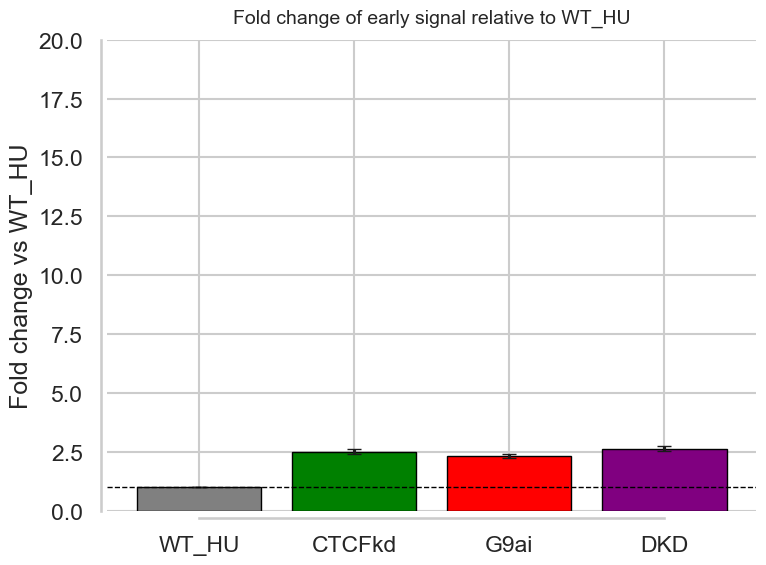

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1) Data dict
# ------------------------------------------------------------
# means_early must be a dict-like: key -> 1D array/list of values
data = means_early

# WT baseline key
WT_KEY = "WT_HU"

# conditions to use
order = [
    "WT_HU",
    "CTCFkd",
    "G9ai",
    "DKD",
]

# ------------------------------------------------------------
# 2) Tidy DataFrame with raw values
# ------------------------------------------------------------
rows = []
for cond in order:
    vals = np.asarray(data[cond], dtype=float)
    for v in vals:
        rows.append({"Condition": cond, "Value": v})

df = pd.DataFrame(rows)
df["Condition"] = pd.Categorical(df["Condition"], categories=order, ordered=True)

# ------------------------------------------------------------
# 3) Palette
# ------------------------------------------------------------
cond_palette = {
    "WT_HU":  "grey",
    "G9ai":   "red",
    "CTCFkd": "green",
    "DKD":    "purple",
}

# ------------------------------------------------------------
# 4) Compute fold change vs WT_HU (per condition)
# ------------------------------------------------------------
wt_vals = np.asarray(data[WT_KEY], dtype=float)
wt_mean = wt_vals.mean()

plot_conds = order  # same as order, but kept explicit

fc_means = []
fc_sems  = []

for cond in plot_conds:
    vals = np.asarray(data[cond], dtype=float)
    # fold change per replicate
    fc_vals = vals / wt_mean

    fc_means.append(fc_vals.mean())
    if len(fc_vals) > 1:
        fc_sems.append(fc_vals.std(ddof=1) / np.sqrt(len(fc_vals)))
    else:
        fc_sems.append(0.0)

fc_means = np.array(fc_means)
fc_sems  = np.array(fc_sems)

# ------------------------------------------------------------
# 5) Bar plot with error bars (NO p-values)
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(plot_conds))

bars = ax.bar(
    x,
    fc_means,
    yerr=fc_sems,
    capsize=5,
    linewidth=1.0,
    edgecolor="black",
)

# color bars
for bar, cond in zip(bars, plot_conds):
    bar.set_facecolor(cond_palette[cond])

# baseline WT fold change = 1
ax.axhline(1.0, linestyle="--", linewidth=1.0, color="black")

ax.set_xticks(x)
ax.set_xticklabels(plot_conds, rotation=90)
ax.set_ylabel("Fold change vs WT_HU")
ax.set_xlabel("")
ax.set_title("Fold change of early signal relative to WT_HU", fontsize=14, pad=12)

# y-axis 0–10
ax.set_ylim(0, 20)
# ax.set_yticks([0, 2, 4, 6, 8, 10])

sns.despine(offset=5, trim=True)
plt.tight_layout()
plt.savefig("./fig_1/hct_5hrs_lessthan2_foldchange_bar_NOPVAL_20.svg",
            format="svg", dpi=1200)
plt.show()
